# labeled Supervised Learning : Classification & Regression

# *** Regression Algorithms ***

## Linear Regression

input과 output을 선형으로 가정(가설)하고, 많은 가설 중에서 error가 최소인 직선 하나를 찾음

Y_hat = beta0(intercept) + beta1*X

### Simple Linear Regression : Independent Variable (X) 1개

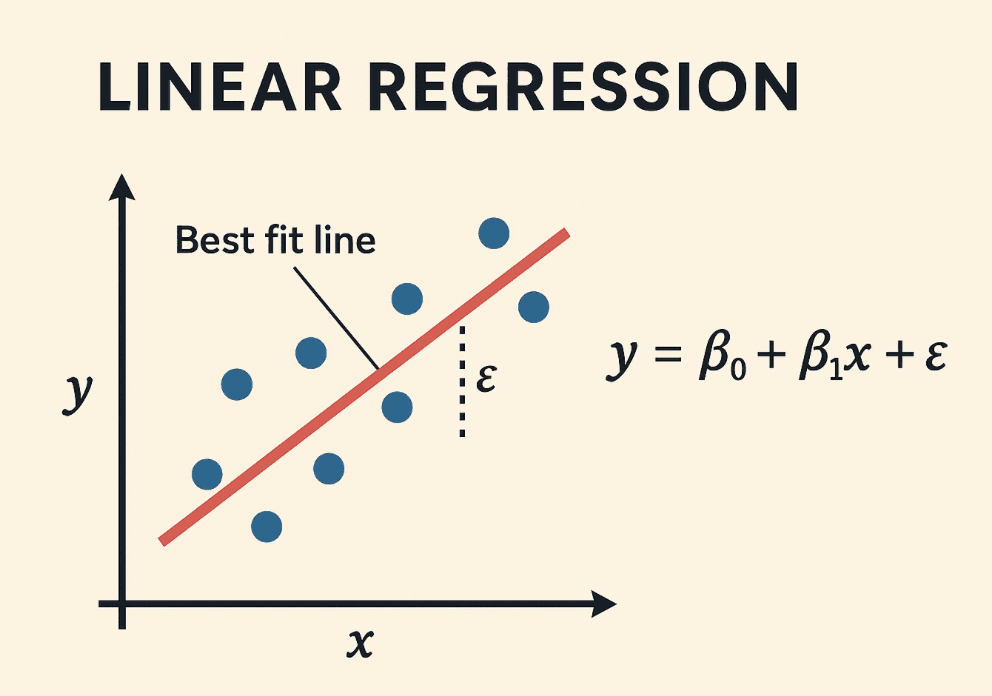

RSS (Residual Rum of Squares) : sum[ {(y_hat) - (y)} ^2 ]

#### MSE (Mean Squared Error) : RSS / n

#### OLS (Ordinary Least Sqares, 최소제곱법)

MSE가 최소가 되는 beta0, beta1 을 찾는 것

#### Gradient Descent (경사하강법)

Cost Function = RSS / 2n

이걸 최소화하기 위해 parameter 조정하는 알고리즘

Deep Learning의 기초

미분값 = 0 를 이용하지 않음.

절차
1. random의 beta 에서 시작
2. 그 점의 경사(gradient) 계산 : 편미분
3. 기울기의 반대 방향으로, 크기에 비례한 만큼 beta를 빼줌 (최솟값을 향해감)
4. 기울기 0 될때까지 반복 or 정한 횟수만큼 반복



### Multiple Linear Regression : X 2개 이상

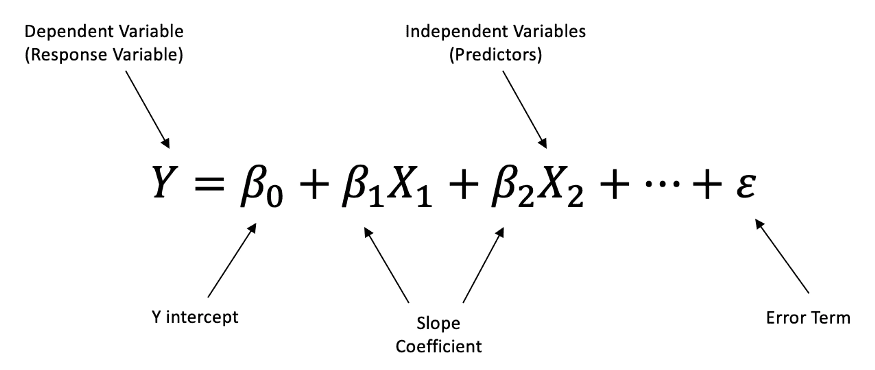

Polynomial Linear Regression : X가 다항식 (X^2등)

## LASSO

L1-norm 페널티를 가진 Linear Regression 방법

L1-norm : 한 벡터요소의 절댓값의 합

MSE가 최소가 되는 가중치와 편향을 찾으면서, 가중치들의 절댓값의 합이 최소가 되게 함.

즉, 가중치의 모든 원소가 0이 되거나 0에 가깝도록 함.
패널티항은 모델에 대한 기여도가 낮은 회귀계수를 0으로 만들 수 있음.

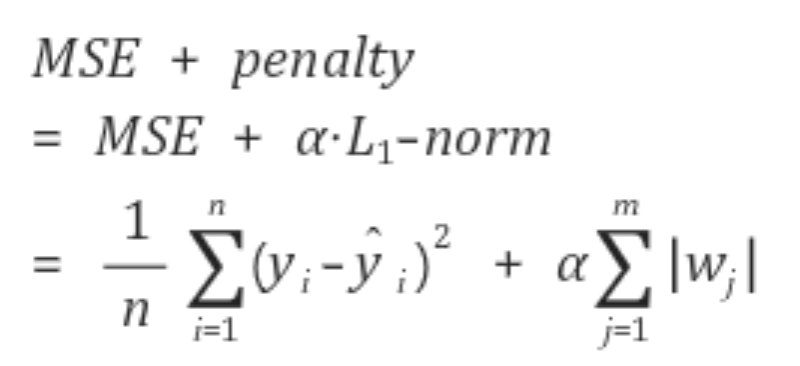

MSE와 penalty항의 합이 최소가 되게 하는 w와 b를 찾는 것

## Ridge

L1-norm 대신에 L2-norm 패널티를 가짐

별로 안 중요한 가중치들은 0에 가까워질 뿐 0이 되지는 않는다

# *************실습********

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 데이터 불러오기

In [5]:
autom = pd.read_csv('https://raw.githubusercontent.com/devdio/flyai_datasets/refs/heads/main/auto-mpg.csv')

In [6]:
autom.shape

(398, 9)

In [7]:
autom.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


### Target : mpg

## EDA

In [8]:
autom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


### horsepower, car name은 문자열임

horsepower에서 NaN 값을 - 이렇게 문자로 표시했을 것

In [10]:
autom['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

물음표로 해뒀군.

In [9]:
autom.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


cylinders : 3 ~ 8

model year : 70 ~ 82

origin : 1, 2, 3

## 데이터 시각화

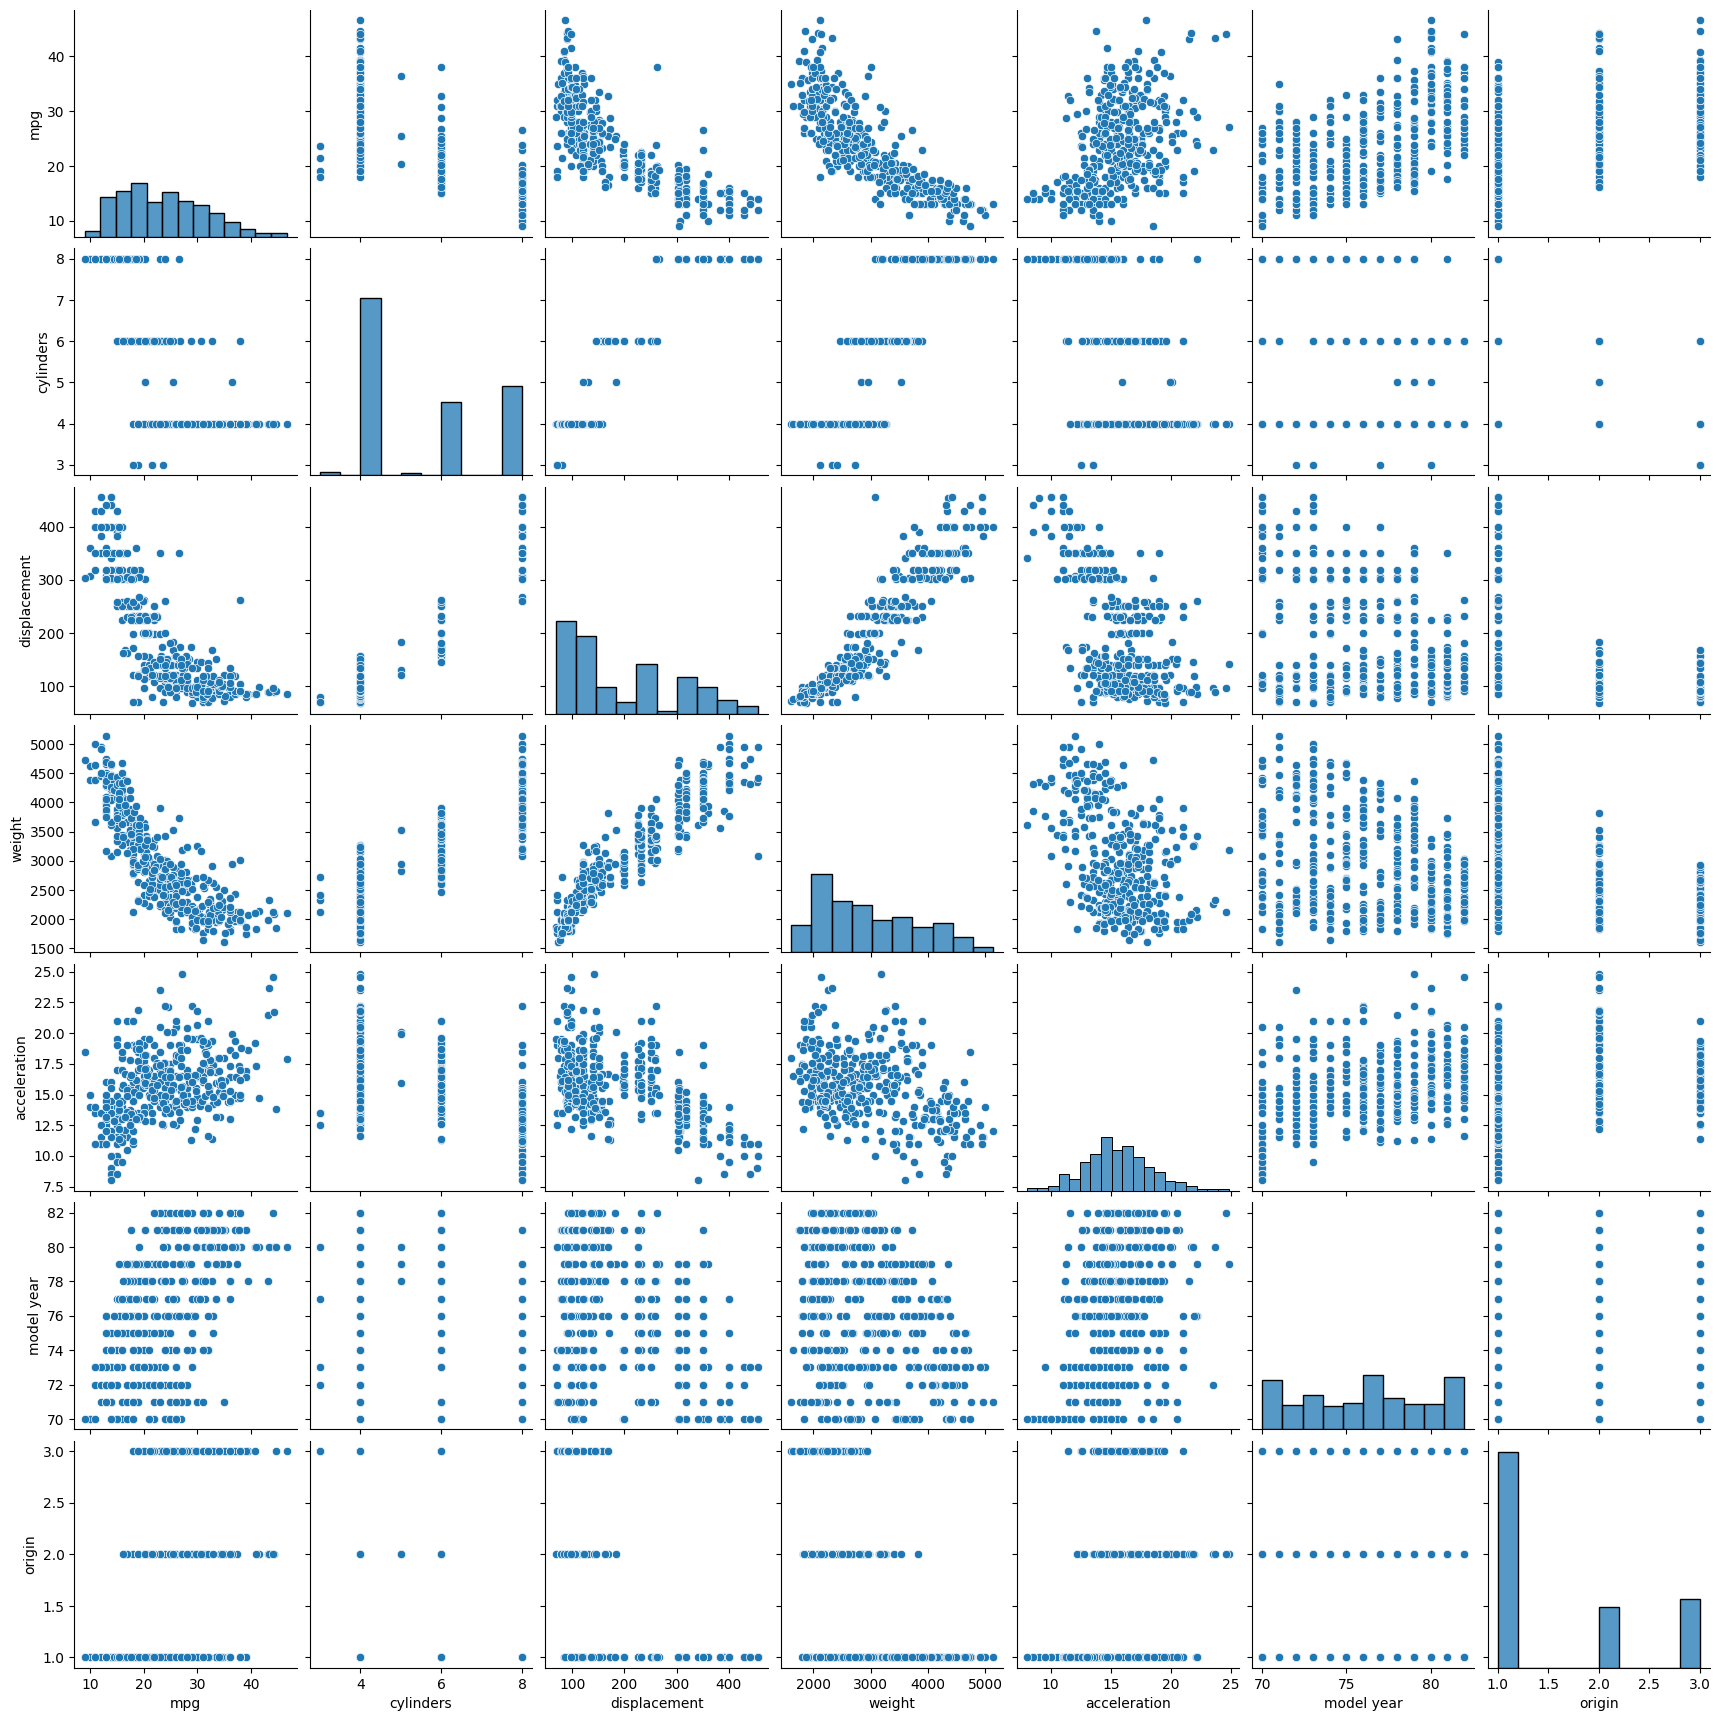

In [11]:
sns.pairplot(autom)

<Axes: >

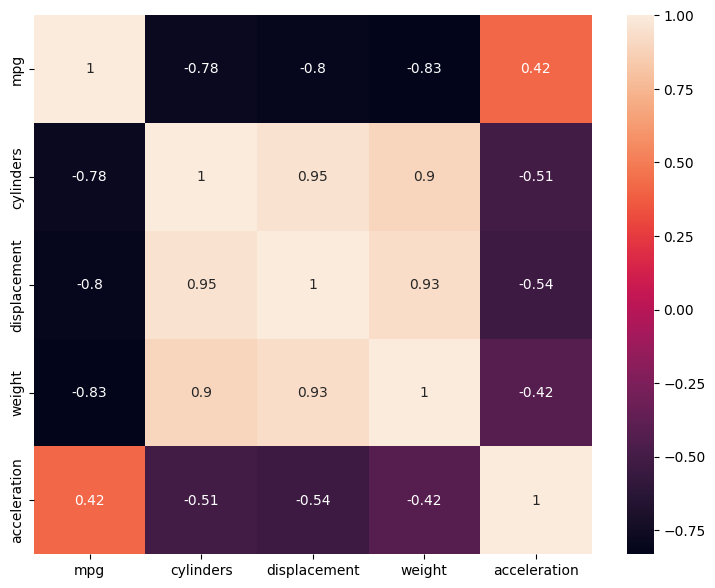

In [12]:
numerical_cols = ['mpg', 'cylinders', 'displacement', 'weight', 'acceleration']
corr = autom[numerical_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True)

## Train, Test 나누기

In [14]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(autom, test_size=0.2, random_state=SEED, shuffle=True)
x_train = train.drop(['mpg', 'car name'], axis=1)
y_train = train['mpg']

## 데이터 전처리

In [15]:
x_train['horsepower'].unique()

array(['150', '88', '68', '60', '95', '175', '52', '65', '198', '190',
       '100', '75', '58', '108', '63', '84', '115', '105', '66', '94',
       '97', '215', '46', '74', '86', '125', '67', '80', '90', '69',
       '110', '133', '145', '72', '85', '116', '70', '61', '91', '140',
       '142', '54', '96', '220', '138', '103', '93', '170', '92', '71',
       '120', '158', '160', '122', '78', '98', '155', '113', '208', '81',
       '?', '165', '48', '79', '132', '49', '129', '76', '149', '200',
       '112', '130', '153', '83', '148', '193', '225', '77', '62', '210',
       '135', '89', '102', '180', '139', '152', '137', '64', '82', '87'],
      dtype=object)

'?'를 nan 으로 바꾸고, 그자리에 평균값을 넣자.

In [21]:
x_train['horsepower'] = x_train['horsepower'].replace('?', np.nan)
x_train['horsepower'] = x_train['horsepower'].astype('float')

### 결측치 해결

In [22]:
x_train.isnull().sum()

,0
cylinders,0
displacement,0
horsepower,5
weight,0
acceleration,0
model year,0
origin,0


In [23]:
m = x_train['horsepower'].mean()
x_train['horsepower'] = x_train['horsepower'].fillna(m)

In [24]:
x_train.isnull().sum()

,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0


### Encoding

x만 필요

cylinders : 3 ~ 8

model year : 70 ~ 82

origin : 1, 2, 3

In [25]:
from sklearn.preprocessing import OneHotEncoder

x_categorical_cols = ['cylinders', 'model year', 'origin']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
x_ohe = pd.DataFrame(
                    data = ohe.fit_transform(x_train[x_categorical_cols]),
                    columns = ohe.get_feature_names_out(x_categorical_cols),
                    index = x_train.index
                    )

x_train_e = pd.concat([x_train.drop(x_categorical_cols, axis=1), x_ohe], axis=1)

### Scaling

x,y 둘다

#### x

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train_e)
x_train_es = scaler.transform(x_train_e)

#### y : scaling 하지말고 log변환 해보자.

정규분포 모양으로 변할것임.

In [27]:
y_train = np.log1p(y_train)

## 모델 학습 linear regression

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train_es, y_train)

LinearRegression()

lr.coef : beta1, beta2....

lr.intercept : beta0

In [29]:
lr.coef_, lr.intercept_

(array([ 0.03567523, -0.07435661, -0.17022676, -0.01200396, -0.02276197,
         0.02381724,  0.0039309 , -0.01670584, -0.00654476, -0.03230115,
        -0.01567147, -0.02760034, -0.04941974, -0.01579049, -0.02100153,
        -0.01101716,  0.00406889,  0.00681035,  0.02562543,  0.05656463,
         0.03710542,  0.04513032, -0.02049691,  0.01057918,  0.01464043]),
 np.float64(3.150744066231133))

## 테스트

### 데이터 전처리

#### 결측치 처리

In [56]:
x_test = test.drop(['mpg', 'car name'], axis=1)
y_test = test['mpg']

In [57]:
x_test['horsepower'].unique()

array(['53', '79', '100', '150', '88', '92', '215', '110', '?', '190',
       '67', '70', '75', '180', '85', '125', '68', '76', '95', '112',
       '83', '130', '52', '90', '120', '167', '86', '74', '65', '230',
       '107', '145', '115', '60', '97', '71', '72', '175', '87', '63',
       '198'], dtype=object)

In [58]:
x_test['horsepower'] = x_test['horsepower'].replace('?', np.nan)
x_test['horsepower'] = x_test['horsepower'].astype('float')

In [59]:
x_test.isnull().sum()

,0
cylinders,0
displacement,0
horsepower,1
weight,0
acceleration,0
model year,0
origin,0


x_test 에는 '?'가 한개 있네.

x_train에서 썼던 평균 똑같은거 그대로 써야함

In [60]:
x_test['horsepower'] = x_test['horsepower'].fillna(m)

In [61]:
x_test.isnull().sum()

,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0


#### Encoding

In [62]:
x_ohe_test = pd.DataFrame(
                    data = ohe.transform(x_test[x_categorical_cols]),
                    columns = ohe.get_feature_names_out(x_categorical_cols),
                    index = x_test.index
                    )

x_test_e = pd.concat([x_test.drop(x_categorical_cols, axis=1), x_ohe_test], axis=1)

#### Scaling

In [63]:
x_test_es = scaler.transform(x_test_e)

#### 테스트 시행

In [64]:
y_pred = lr.predict(x_test_es)

### 결과 확인

로그 역변환

In [65]:
y_predict = np.expm1(y_pred)

그래프 그리기

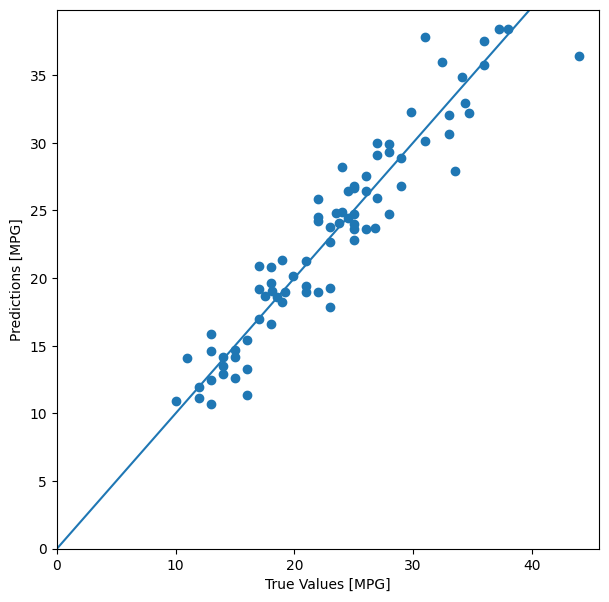

In [66]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_predict)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
plt.plot([-100, 100], [-100, 100])
plt.show()

#### MSE, RMSE, MAE, R-squared 출력

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def print_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    print(f"1. Mean Squared Error (MSE): {mse:.4f}")

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"2. Root Mean Squared Error (RMSE): {rmse:.4f}")

    # MAE 계산
    mae = mean_absolute_error(y_true, y_pred)
    print(f"3. Mean Absolute Error (MAE): {mae:.4f}")

    # R^2 Score 계산
    r2 = r2_score(y_true, y_pred)
    print(f"4. R-squared (R^2) Score: {r2:.4f}")

print_metrics(y_test, y_predict)

1. Mean Squared Error (MSE): 5.6748
2. Root Mean Squared Error (RMSE): 2.3822
3. Mean Absolute Error (MAE): 1.8299
4. R-squared (R^2) Score: 0.8945


# Decision Tree Regression

classification 뿐 아니라 regression에도 사용되는 decision tree 로도 돌려보자

In [69]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(random_state= SEED)
dtr.fit(x_train_es, y_train)

y_pred_dtr = dtr.predict(x_test_es)
y_pred_dtr = np.expm1(y_pred_dtr)

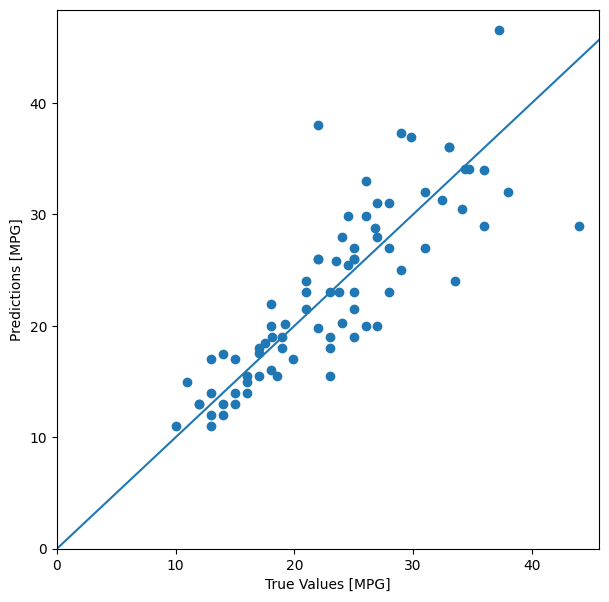

In [70]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_dtr)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
plt.plot([-100, 100], [-100, 100])
plt.show()